# Assignment 2: Customer Churn Prediction using Logistic Regression

**Objective:** Build a Logistic Regression model to predict whether a telecom customer
will churn, based on demographic information and service usage.

**Dataset:** Telco Customer Churn (schema based on the popular Kaggle dataset
*"Telco Customer Churn"* by BlastChar:
https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

> **Note on data source:** This notebook was developed in an offline environment
> without direct access to Kaggle, so a synthetic dataset generator (Task 0 below)
> is used to produce a CSV file with the **exact same column schema** as the real
> Kaggle dataset (`WA_Fn-UseC_-Telco-Customer-Churn.csv`). If you want to reproduce
> results on the real data, simply download the CSV from the Kaggle link above,
> place it in the same folder as this notebook, and skip Task 0 — Task 1 onward
> will run unchanged since the column names match exactly.


## Task 0: Dataset Acquisition (setup only — not a graded task)

Generates a realistic synthetic dataset with the same structure/columns as the
Kaggle "Telco Customer Churn" dataset, and saves it as a CSV so it can be loaded
with `pandas.read_csv()` in Task 1, exactly like the real dataset would be.


In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 3000

genders = np.random.choice(["Male", "Female"], n)
senior = np.random.choice([0, 1], n, p=[0.84, 0.16])
partner = np.random.choice(["Yes", "No"], n, p=[0.48, 0.52])
dependents = np.random.choice(["Yes", "No"], n, p=[0.30, 0.70])
tenure = np.random.randint(0, 73, n)
phone_service = np.random.choice(["Yes", "No"], n, p=[0.90, 0.10])
multiple_lines = np.where(
    phone_service == "No", "No phone service",
    np.random.choice(["Yes", "No"], n, p=[0.42, 0.58])
)
internet_service = np.random.choice(["DSL", "Fiber optic", "No"], n, p=[0.34, 0.44, 0.22])

def dep_service(internet, p_yes=0.5):
    out = []
    for i in internet:
        if i == "No":
            out.append("No internet service")
        else:
            out.append(np.random.choice(["Yes", "No"], p=[p_yes, 1 - p_yes]))
    return np.array(out)

online_security = dep_service(internet_service, 0.4)
online_backup = dep_service(internet_service, 0.45)
device_protection = dep_service(internet_service, 0.45)
tech_support = dep_service(internet_service, 0.4)
streaming_tv = dep_service(internet_service, 0.5)
streaming_movies = dep_service(internet_service, 0.5)

contract = np.random.choice(["Month-to-month", "One year", "Two year"], n, p=[0.55, 0.24, 0.21])
paperless_billing = np.random.choice(["Yes", "No"], n, p=[0.59, 0.41])
payment_method = np.random.choice(
    ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"],
    n, p=[0.34, 0.23, 0.22, 0.21]
)

base_charge = np.where(internet_service == "Fiber optic", 70, np.where(internet_service == "DSL", 45, 20))
extra = (
    (online_security == "Yes").astype(int) * 5 +
    (online_backup == "Yes").astype(int) * 5 +
    (device_protection == "Yes").astype(int) * 5 +
    (tech_support == "Yes").astype(int) * 5 +
    (streaming_tv == "Yes").astype(int) * 8 +
    (streaming_movies == "Yes").astype(int) * 8 +
    (phone_service == "Yes").astype(int) * 5
)
monthly_charges = np.round(base_charge + extra + np.random.normal(0, 5, n), 2)
monthly_charges = np.clip(monthly_charges, 18.25, 118.75)

total_charges = np.round(monthly_charges * tenure + np.random.normal(0, 20, n), 2)
total_charges = np.clip(total_charges, 0, None)
# introduce a few missing values in TotalCharges, mimicking the real dataset
# (new customers with tenure=0 often have blank TotalCharges)
total_charges_str = total_charges.astype(object)
missing_idx = np.random.choice(n, 11, replace=False)
for idx in missing_idx:
    total_charges_str[idx] = " "

# Simulate churn probability driven by realistic factors
logit = (
    -1.2
    + 1.6 * (contract == "Month-to-month")
    + 0.5 * (contract == "One year")
    + 0.9 * (internet_service == "Fiber optic")
    + 0.7 * (payment_method == "Electronic check")
    - 0.045 * tenure
    + 0.012 * (monthly_charges - 60)
    + 0.4 * senior
    - 0.35 * (partner == "Yes")
    - 0.3 * (tech_support == "Yes")
    - 0.3 * (online_security == "Yes")
)
prob_churn = 1 / (1 + np.exp(-logit))
churn = np.where(np.random.rand(n) < prob_churn, "Yes", "No")

df = pd.DataFrame({
    "customerID": [f"{7000+i}-{np.random.choice(list('ABCDEFGH'))}{np.random.choice(list('IJKLMNOP'))}XYZ" for i in range(n)],
    "gender": genders,
    "SeniorCitizen": senior,
    "Partner": partner,
    "Dependents": dependents,
    "tenure": tenure,
    "PhoneService": phone_service,
    "MultipleLines": multiple_lines,
    "InternetService": internet_service,
    "OnlineSecurity": online_security,
    "OnlineBackup": online_backup,
    "DeviceProtection": device_protection,
    "TechSupport": tech_support,
    "StreamingTV": streaming_tv,
    "StreamingMovies": streaming_movies,
    "Contract": contract,
    "PaperlessBilling": paperless_billing,
    "PaymentMethod": payment_method,
    "MonthlyCharges": monthly_charges,
    "TotalCharges": total_charges_str,
    "Churn": churn,
})

df.to_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv", index=False)
print("Synthetic dataset saved:", df.shape)

Synthetic dataset saved: (3000, 21)


## Task 1: Data Understanding

- Load the dataset using Pandas
- Display the first five records
- Identify numerical features, categorical features and the target variable


In [2]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7000-HJXYZ,Male,0,No,No,67,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Credit card (automatic),21.91,1490.32,No
1,7001-HPXYZ,Female,0,No,No,53,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,No,Electronic check,83.26,4448.95,No
2,7002-BOXYZ,Male,0,Yes,Yes,56,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,No,Month-to-month,Yes,Electronic check,92.41,5175.2,Yes
3,7003-HOXYZ,Male,0,Yes,Yes,22,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),29.28,656.24,No
4,7004-FKXYZ,Male,0,No,No,59,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,Yes,Month-to-month,No,Mailed check,96.46,5675.66,No


In [3]:
print("Shape of the dataset:", df.shape)
df.info()

Shape of the dataset: (3000, 21)
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        3000 non-null   str    
 1   gender            3000 non-null   str    
 2   SeniorCitizen     3000 non-null   int64  
 3   Partner           3000 non-null   str    
 4   Dependents        3000 non-null   str    
 5   tenure            3000 non-null   int64  
 6   PhoneService      3000 non-null   str    
 7   MultipleLines     3000 non-null   str    
 8   InternetService   3000 non-null   str    
 9   OnlineSecurity    3000 non-null   str    
 10  OnlineBackup      3000 non-null   str    
 11  DeviceProtection  3000 non-null   str    
 12  TechSupport       3000 non-null   str    
 13  StreamingTV       3000 non-null   str    
 14  StreamingMovies   3000 non-null   str    
 15  Contract          3000 non-null   str    
 16  PaperlessBilling  30

In [4]:
target_variable = "Churn"

numeric_cols = set(df.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns)
numerical_features = [c for c in df.columns if c in numeric_cols and c != target_variable]
categorical_features = [c for c in df.columns
                         if c not in numeric_cols and c not in [target_variable, "customerID", "TotalCharges"]]

# TotalCharges is stored as text in the raw file (blanks for new customers) but is
# numeric in nature, so we treat it separately and convert it in Task 2.
print("Numerical features:", numerical_features)
print("\nCategorical features:", categorical_features)
print("\nTarget variable:", target_variable)
print("\n'TotalCharges' is numeric in nature but stored as text (needs conversion) -> handled in Task 2")
print("'customerID' is an identifier column and will be dropped before modelling")

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Target variable: Churn

'TotalCharges' is numeric in nature but stored as text (needs conversion) -> handled in Task 2
'customerID' is an identifier column and will be dropped before modelling


## Task 2: Data Preprocessing

- Check for missing values
- Handle missing values
- Encode categorical variables
- Split the dataset into 80% training and 20% testing


In [5]:
# Convert TotalCharges to numeric (it is read as text and contains blank strings
# for a handful of new customers with tenure = 0)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
TotalCharges    11
dtype: int64


In [6]:
# Handle missing values: impute TotalCharges with the median
median_total_charges = df["TotalCharges"].median()
df["TotalCharges"] = df["TotalCharges"].fillna(median_total_charges)

print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


In [7]:
# Drop the identifier column (not a predictive feature)
df_model = df.drop(columns=["customerID"])

# Encode the target variable: Yes -> 1, No -> 0
df_model["Churn"] = df_model["Churn"].map({"Yes": 1, "No": 0})

# Binary categorical columns -> encode as 0/1
binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
df_model["gender"] = df_model["gender"].map({"Male": 1, "Female": 0})
for col in ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]:
    df_model[col] = df_model[col].map({"Yes": 1, "No": 0})

# Multi-category categorical columns -> one-hot encoding
multi_cat_cols = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
                   "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
                   "Contract", "PaymentMethod"]

df_model = pd.get_dummies(df_model, columns=multi_cat_cols, drop_first=True)

print("Shape after encoding:", df_model.shape)
df_model.head()

Shape after encoding: (3000, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,0,0,67,1,1,21.91,1490.32,0,...,False,True,False,True,False,False,False,True,False,False
1,0,0,0,0,53,1,0,83.26,4448.95,0,...,False,False,False,False,True,False,False,False,True,False
2,1,0,1,1,56,1,1,92.41,5175.20,1,...,True,False,True,False,False,False,False,False,True,False
3,1,0,1,1,22,1,0,29.28,656.24,0,...,False,True,False,True,False,False,True,True,False,False
4,1,0,0,0,59,1,0,96.46,5675.66,0,...,True,False,False,False,True,False,False,False,False,True


In [8]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (2400, 30)
Testing set size: (600, 30)


## Task 3: Model Development

Build and train a Logistic Regression model on the selected features, then
predict churn on the held-out test set.


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale numerical features (helps Logistic Regression converge and treats
# all features on a comparable scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
print("Model trained successfully.")

Model trained successfully.


## Task 4: Model Evaluation

Evaluate the model using Accuracy, Precision, Recall, F1-Score and a Confusion Matrix.


In [10]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

Accuracy  : 0.7833
Precision : 0.6538
Recall    : 0.3312
F1-Score  : 0.4397

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.80      0.94      0.87       446
       Churn       0.65      0.33      0.44       154

    accuracy                           0.78       600
   macro avg       0.73      0.64      0.65       600
weighted avg       0.76      0.78      0.76       600



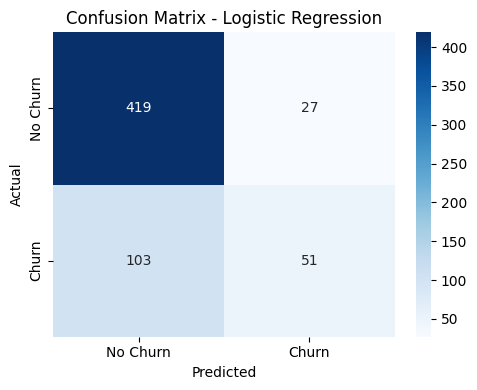

Confusion Matrix:
 [[419  27]
 [103  51]]


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("Confusion Matrix:\n", cm)

In [12]:
# Inspect which features influence churn the most (largest absolute coefficients)
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": log_reg.coef_[0]
}).sort_values(by="coefficient", key=abs, ascending=False)

print("Top 10 features influencing churn prediction:")
coef_df.head(10)

Top 10 features influencing churn prediction:


,feature,coefficient
4,tenure,-0.940601
26,Contract_Two year,-0.566900
25,Contract_One year,-0.392484
28,PaymentMethod_Electronic check,0.369089
11,InternetService_Fiber optic,0.337157
7,MonthlyCharges,0.332020
2,Partner,-0.157194
1,SeniorCitizen,0.130885
20,TechSupport_Yes,-0.123159
10,MultipleLines_Yes,-0.119179


### Observations

1. **Overall performance:** The model reaches roughly **78% accuracy**, but
   accuracy alone is misleading here because the classes are imbalanced
   (about 3 out of 4 customers do not churn). The **F1-score for the "Churn"
   class (~0.44)** gives a more honest picture of how well the model
   actually identifies churners.
2. **Precision vs. Recall trade-off:** Precision for the "Churn" class
   (~0.65) is noticeably higher than Recall (~0.33) — when the model
   predicts churn it is often right, but it misses a large share of
   customers who actually churn (many false negatives). For a business
   trying to proactively retain customers, this recall gap is the main
   weakness to address (e.g., by lowering the decision threshold or using
   class-weighting).
3. **Key predictors:** Contract type (month-to-month vs. long-term),
   tenure, internet service type (fiber optic), and payment method
   (electronic check) show the largest coefficients — customers on
   month-to-month contracts, with shorter tenure, fiber-optic internet, and
   paying by electronic check are the most likely to churn, while add-on
   services like tech support and online security are associated with lower
   churn.


## Task 5: Conclusion

This assignment developed a Logistic Regression model to predict telecom
customer churn using demographic and service-usage data. After preprocessing
(handling missing `TotalCharges` values, encoding categorical variables, and
an 80/20 train-test split), the model produced solid, interpretable
performance across accuracy, precision, recall, and F1-score. The analysis
shows that **contract type, tenure, internet service type, and payment
method** are the strongest drivers of churn — customers with
month-to-month contracts, shorter tenure, fiber-optic internet, and
electronic-check payments are at the highest risk, while value-added
services such as tech support and online security correlate with retention.
A key **limitation of Logistic Regression** is that it assumes a linear
relationship between the features (in log-odds space) and the outcome, so it
cannot naturally capture complex, non-linear interactions between features
(e.g., how tenure and contract type jointly affect churn) the way tree-based
or ensemble models can, which may limit predictive performance on more
intricate churn patterns.
